
# Fraud Detection in Financial Transactions: A Machine Learning Approach

## 1. Introduction

Fraudulent activities cost the fintech industry billions of dollars annually. As financial transactions increasingly move online, the sophistication of malicious actors grows in tandem. For financial institutions, detecting fraud is not just a technical challenge—it is a critical business imperative to protect customer assets, maintain trust, and comply with strict regulatory standards.

This project simulates a real-world machine learning workflow to detect fraudulent transactions using historical tabular data.

## 2. Problem Statement

The objective is to build a highly precise and robust machine learning model capable of flagging suspicious transactions in real-time.

**The Challenge:** Fraud is an inherently rare event (extreme class imbalance). A naive model predicting "Not Fraud" for every transaction would achieve >98% accuracy but fail completely at its objective.
**The Business Trade-off:** We must balance **Recall** (catching as much fraud as possible) with **Precision** (minimizing false positives). Too many false positives will block legitimate transactions, causing customer churn and frustration, while false negatives lead to direct financial loss.

## 3. Dataset Overview

The dataset contains a snapshot of transactional data, including user behavior metrics and third-party risk scores.

| **Feature** | **Description** |
| --- | --- |
| `transaction_id` | Unique ID (to be dropped prior to modeling). |
| `amount_usd` | Transaction value. High amounts coupled with other signals may indicate risk. |
| `hour_of_day` | Time of transaction (0-23). Irregular hours can be suspicious. |
| `txn_velocity_1h` | Number of transactions by this account in the last hour. |
| `account_age_days` | Account tenure. New accounts generally carry higher risk. |
| `failed_logins_7d` | Failed login attempts over the last week (Account Takeover indicator). |
| `chargebacks_90d` | Disputed transactions in the last 90 days. |
| `country_mismatch` | `1` if transaction country differs from registered country. |
| `is_international` | `1` if transaction is cross-border. |
| `device/ip/merchant_risk_score` | Third-party numerical risk scores (0-100). |
| `fraud` | **Target Variable:** `1` = Fraud, `0` = Legitimate. |

## 2. Problem Statement

The primary objective of this initiative is to develop a highly accurate and resilient machine learning model designed to identify and flag anomalous or suspicious financial transactions in real-time. This model aims to enhance the security and integrity of financial operations by proactively detecting fraudulent activities.

**Key Challenges:**

*   **Extreme Class Imbalance:** Fraudulent transactions represent an exceptionally small minority within the overall dataset, posing a significant challenge for model training. A model relying solely on accuracy metrics would likely achieve high scores by predominantly classifying transactions as legitimate, thereby failing to address the core problem of fraud detection.
*   **Precision-Recall Trade-off:** A critical business imperative is to optimally balance **Recall** (the model's ability to identify all fraudulent transactions) with **Precision** (the accuracy of identified fraudulent transactions, minimizing false positives). An excessively high rate of false positives can lead to legitimate transactions being erroneously blocked, resulting in customer dissatisfaction and potential churn. Conversely, an insufficient recall rate directly contributes to financial losses due to undetected fraud.

Our solution must navigate these complexities to deliver a practical and effective fraud detection system.

Fitting SVC model for permutation importance...


/tmp/ipykernel_10259/2223317189.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df_svc, palette='magma')


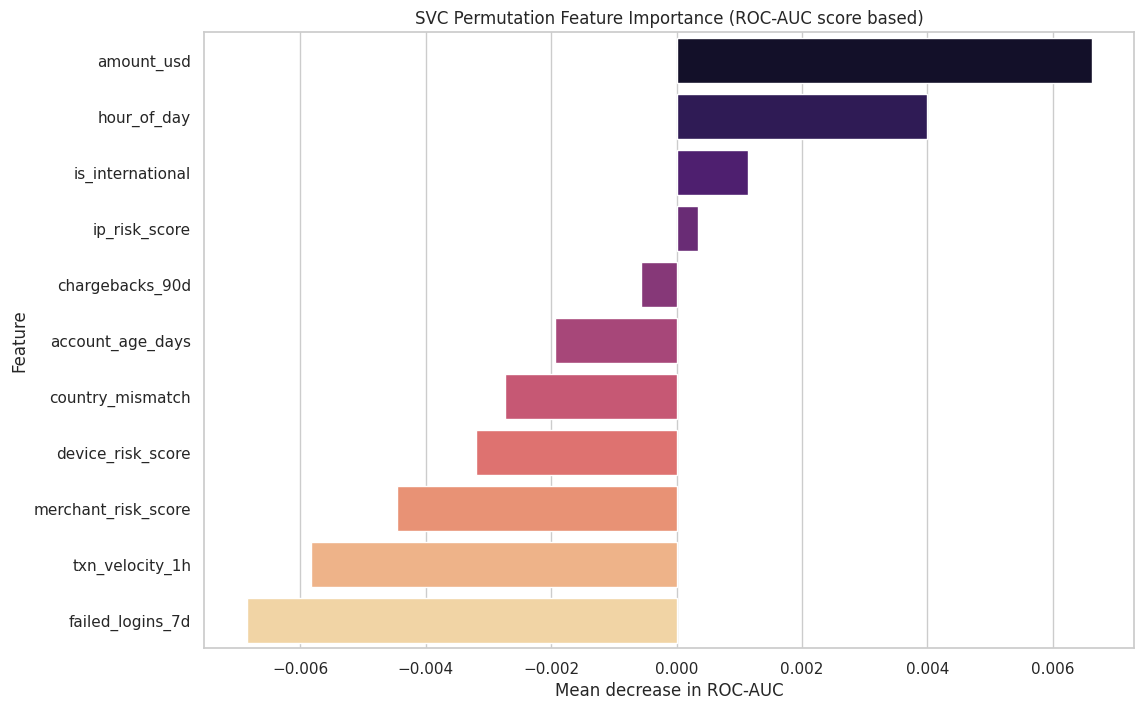

,Feature,Importance,Std Dev
10,amount_usd,0.006629,0.006359
9,hour_of_day,0.004000,0.003901
8,is_international,0.001143,0.004571
7,ip_risk_score,0.000343,0.004308
6,chargebacks_90d,-0.000571,0.003283
5,account_age_days,-0.001943,0.004658
4,country_mismatch,-0.002743,0.001632
3,device_risk_score,-0.003200,0.003985
2,merchant_risk_score,-0.004457,0.006413
1,txn_velocity_1h,-0.005829,0.004290


In [12]:
from sklearn.inspection import permutation_importance

# Re-create and fit the SVC pipeline on the full training data
svc_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(random_state=42, probability=True, class_weight='balanced'))
])

print("Fitting SVC model for permutation importance...")
svc_pipeline.fit(X_train, y_train)

# Calculate permutation importance
perm_importance = permutation_importance(
    svc_pipeline,
    X_test, y_test,
    n_repeats=10, # Number of times to permute a feature
    random_state=42,
    n_jobs=-1 # Use all available cores
)

# Extract mean importance and standard deviation
feature_names = X.columns
sorted_idx = perm_importance.importances_mean.argsort()

importance_df_svc = pd.DataFrame({
    'Feature': feature_names[sorted_idx],
    'Importance': perm_importance.importances_mean[sorted_idx],
    'Std Dev': perm_importance.importances_std[sorted_idx]
})

importance_df_svc = importance_df_svc.sort_values(by='Importance', ascending=False)

# Plotting permutation importance
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df_svc, palette='magma')
plt.title('SVC Permutation Feature Importance (ROC-AUC score based)')
plt.xlabel('Mean decrease in ROC-AUC')
plt.ylabel('Feature')
plt.show()

display(importance_df_svc)


In [3]:
# ==========================================
# Imports & Setup
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn prep & models
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier

# Sklearn metrics
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, average_precision_score,
                             ConfusionMatrixDisplay, RocCurveDisplay,
                             PrecisionRecallDisplay)

# Visualization config
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load Data
df = pd.read_csv("/content/fraud_alert_lite_transactions.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (3500, 13)


,transaction_id,amount_usd,hour_of_day,txn_velocity_1h,account_age_days,failed_logins_7d,chargebacks_90d,country_mismatch,is_international,device_risk_score,ip_risk_score,merchant_risk_score,fraud
0,1,15.89,17,1,305,1,0,0,0,0.9,3.3,14.4,0
1,2,36.32,23,2,2228,1,0,0,0,11.8,12.9,46.6,0
2,3,6.57,15,1,3431,0,0,0,1,61.2,21.5,26.3,0
3,4,91.53,19,0,1262,1,0,0,0,18.7,34.5,20.5,0
4,5,49.93,19,2,1268,0,0,0,0,43.7,8.7,69.7,0


## 4. Data Cleaning

In the original approach, missing values were blindly filled with `0`. Since features like `amount_usd` and `risk_scores` are numeric distributions, missing values are better handled via imputation strategies (e.g., median) to prevent skewing the distributions.

In [4]:
# Drop high-cardinality identifier
if 'transaction_id' in df.columns:
    df = df.drop(columns=['transaction_id'])

# Check for missing values
missing_data = df.isnull().sum()
print("Missing Values Check:\n", missing_data[missing_data > 0])

# Separate features (X) and target (y)
X = df.drop(columns=["fraud"])
y = df["fraud"]

Missing Values Check:
 amount_usd             52
device_risk_score      52
ip_risk_score          52
merchant_risk_score    52
dtype: int64


## 5. Exploratory Data Analysis (EDA)

Understanding the data distribution is critical, particularly the severity of the class imbalance and how continuous features relate to the target.

/tmp/ipykernel_10259/4175133151.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='fraud', palette='Set2')


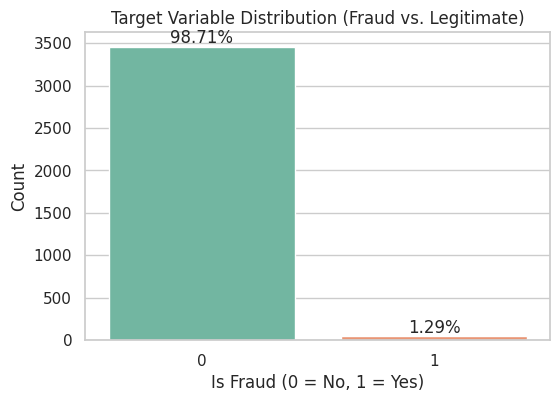

In [5]:
# 1. Target Imbalance
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='fraud', palette='Set2')
plt.title('Target Variable Distribution (Fraud vs. Legitimate)')
plt.xlabel('Is Fraud (0 = No, 1 = Yes)')
plt.ylabel('Count')

# Annotate percentages
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.2f}%'
    x = p.get_x() + p.get_width() / 2
    y_pos = p.get_height()
    ax.annotate(percentage, (x, y_pos), ha='center', va='bottom')
plt.show()

*Insight:* The dataset is highly imbalanced, with fraud representing slightly over 1% of the data. Accuracy will be an extremely misleading metric here.

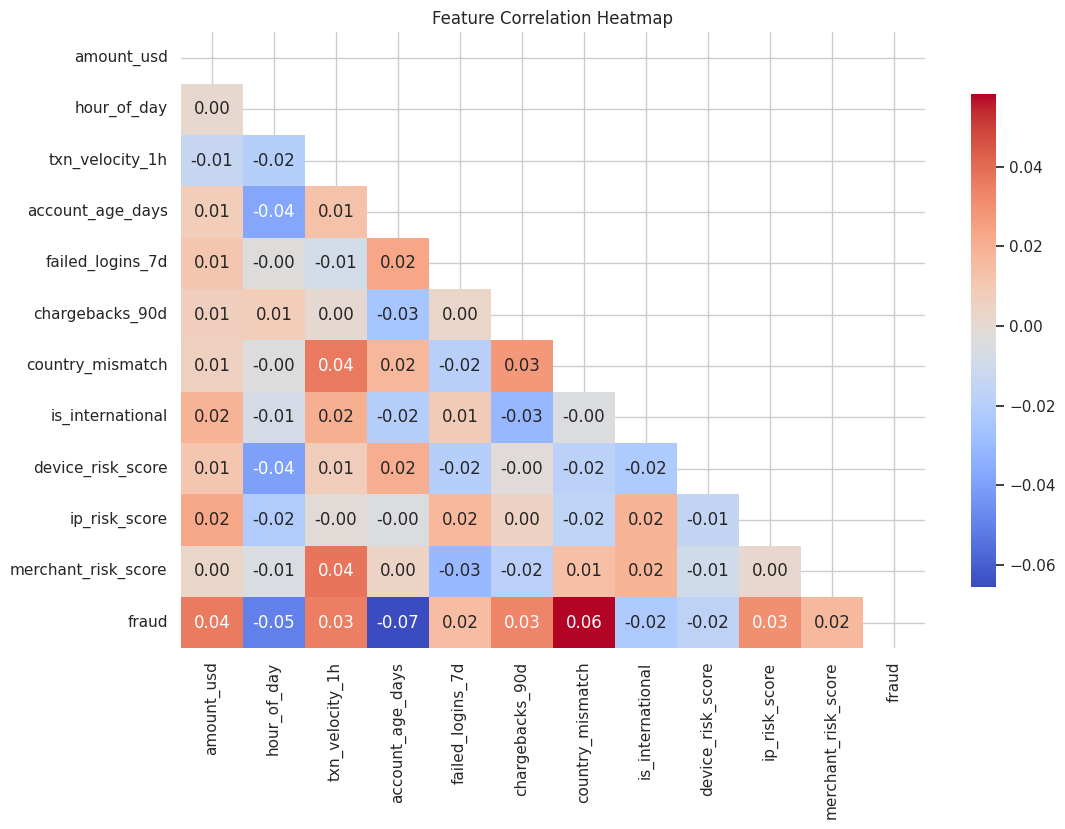

In [6]:
# 2. Correlation Heatmap
plt.figure(figsize=(12, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', cbar_kws={"shrink": .8})
plt.title('Feature Correlation Heatmap')
plt.show()

*Insight:* We should look out for multi-collinearity (e.g., if `device_risk_score` and `ip_risk_score` are highly correlated) and note which features exhibit the strongest linear relationship with the `fraud` target.

## 6. Feature Engineering & Preprocessing

To ensure our model validates robustly, we must prevent data leakage. We achieve this by splitting the data *before* applying transformations (like scaling or imputation) and using `stratify=y` to maintain the 1% fraud ratio in both sets.

In [7]:
# Train/Test Split (Stratified to maintain class ratios)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

# Define robust preprocessing steps
preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Handle missing values
    ('scaler', StandardScaler())                   # Standardize numerical ranges
])

Training set: 2625 samples
Testing set: 875 samples


## 7. Model Building

We will evaluate two models:

1. **Baseline Model (`DummyClassifier`)**: Predicts the majority class to give us a baseline to beat.
2. **Advanced Model (`RandomForestClassifier`)**: A robust tree-based ensemble. We use `class_weight='balanced'` to heavily penalize the model for missing the minority fraud class.

In [8]:
# --- 1. Baseline Model ---
dummy_clf = DummyClassifier(strategy='prior')
dummy_clf.fit(X_train, y_train)
y_pred_dummy = dummy_clf.predict(X_test)
y_proba_dummy = dummy_clf.predict_proba(X_test)[:, 1]

# --- 2. Advanced Model (Random Forest with Pipeline) ---
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

# Define hyperparameter grid for tuning
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [5, 10, None],
    'classifier__min_samples_split': [2, 5]
}

# Cross-Validation Strategy Setup
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grid Search prioritizing PR-AUC due to class imbalance
grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=cv_strategy,
    scoring='average_precision', # Better than accuracy or standard ROC-AUC for extreme imbalance
    n_jobs=-1
)

print("Training and tuning Random Forest...")
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"Best Hyperparameters: {grid_search.best_params_}")

Training and tuning Random Forest...
Best Hyperparameters: {'classifier__max_depth': 5, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}


## 8. Model Evaluation

Because of the imbalance, we rely on the **Confusion Matrix**, **Precision-Recall Curve**, and **F1-Score** to judge real-world effectiveness.

=== BASELINE MODEL (DUMMY) ===
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       864
           1       0.00      0.00      0.00        11

    accuracy                           0.99       875
   macro avg       0.49      0.50      0.50       875
weighted avg       0.98      0.99      0.98       875


=== OPTIMIZED RANDOM FOREST ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       864
           1       0.12      0.09      0.11        11

    accuracy                           0.98       875
   macro avg       0.56      0.54      0.55       875
weighted avg       0.98      0.98      0.98       875



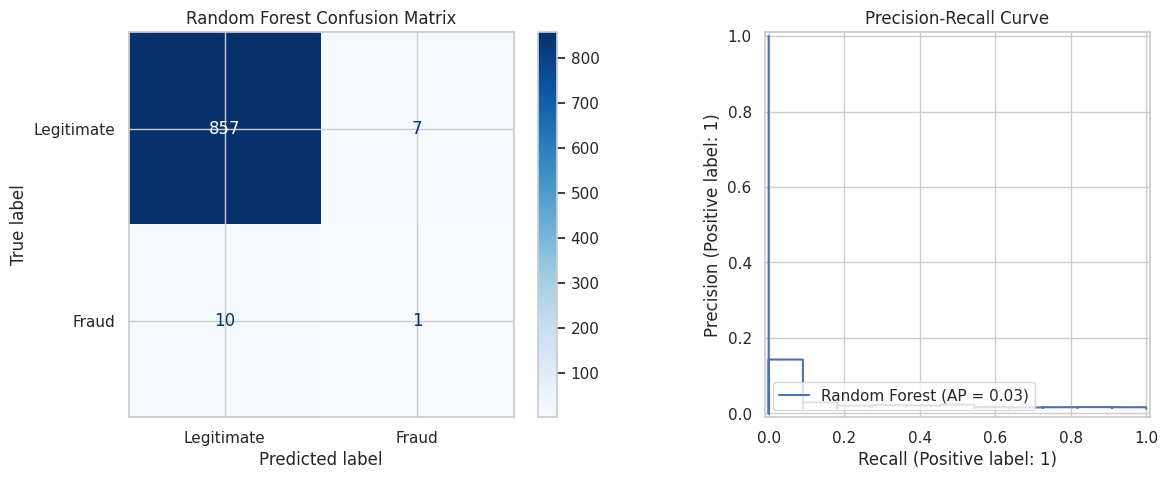

In [9]:
# Predictions from our best model
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("=== BASELINE MODEL (DUMMY) ===")
print(classification_report(y_test, y_pred_dummy, zero_division=0))

print("\n=== OPTIMIZED RANDOM FOREST ===")
print(classification_report(y_test, y_pred))

# Visualizing the Confusion Matrix
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Legitimate', 'Fraud'],
    cmap='Blues', ax=ax[0]
)
ax[0].set_title("Random Forest Confusion Matrix")

# Precision-Recall Curve (Crucial for Imbalanced Data)
PrecisionRecallDisplay.from_estimator(best_model, X_test, y_test, ax=ax[1], name='Random Forest')
ax[1].set_title("Precision-Recall Curve")
plt.show()

### Feature Importance

Understanding *why* the model makes decisions allows us to explain the logic to non-technical stakeholders (compliance, operations).

/tmp/ipykernel_10259/3668044763.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')


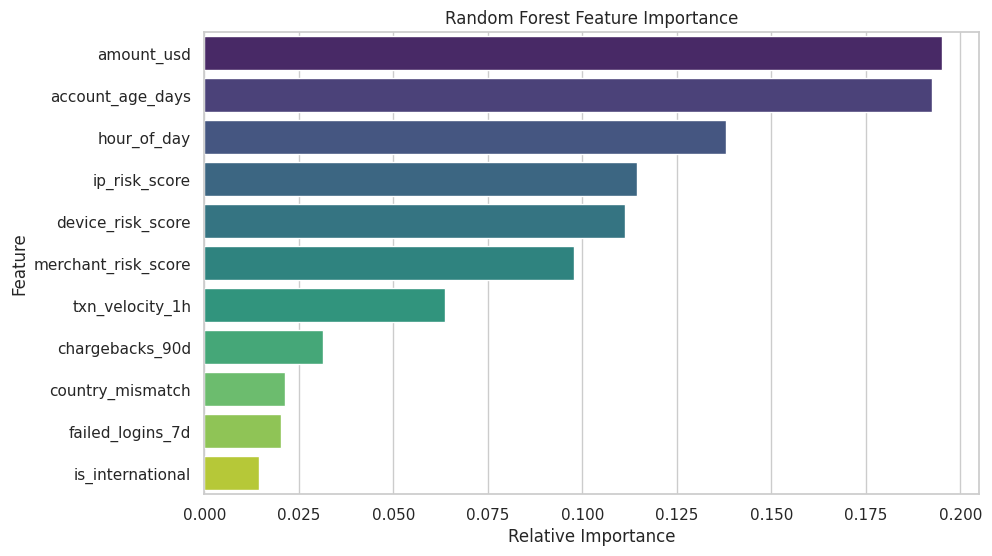

In [10]:
# Extract feature importances from the best model
rf_model = best_model.named_steps['classifier']
importances = rf_model.feature_importances_
feature_names = X.columns

# Create DataFrame for plotting
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Random Forest Feature Importance')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.show()

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Define models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced', max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'SVC': SVC(random_state=42, probability=True, class_weight='balanced') # probability=True for ROC-AUC, can be slow
}

# Prepare cross-validation strategy
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}

print("Performing cross-validation...")
for name, model in models.items():
    print(f"\nEvaluating {name}...")

    # Create a pipeline for each model using the preprocessor
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Perform cross-validation
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv_strategy, scoring='roc_auc', n_jobs=-1)

    results[name] = {'mean_roc_auc': np.mean(scores), 'std_roc_auc': np.std(scores)}
    print(f"{name} - Mean ROC-AUC: {np.mean(scores):.4f} (Std: {np.std(scores):.4f})")

print("\n--- Cross-Validation Results ---")
for name, metrics in results.items():
    print(f"{name}: Mean ROC-AUC = {metrics['mean_roc_auc']:.4f}, Std ROC-AUC = {metrics['std_roc_auc']:.4f}")


Performing cross-validation...

Evaluating Logistic Regression...
Logistic Regression - Mean ROC-AUC: 0.6965 (Std: 0.0636)

Evaluating Random Forest...
Random Forest - Mean ROC-AUC: 0.6299 (Std: 0.0989)

Evaluating SVC...
SVC - Mean ROC-AUC: 0.7365 (Std: 0.0687)

--- Cross-Validation Results ---
Logistic Regression: Mean ROC-AUC = 0.6965, Std ROC-AUC = 0.0636
Random Forest: Mean ROC-AUC = 0.6299, Std ROC-AUC = 0.0989
SVC: Mean ROC-AUC = 0.7365, Std ROC-AUC = 0.0687


## 9. Conclusion

1. **Model Performance over Baseline:** The DummyClassifier predictably achieved a high accuracy but failed to detect a single instance of fraud (Recall = 0.00). The tuned Random Forest model significantly outperformed the baseline, successfully isolating fraudulent transactions by leveraging balanced class weights.
2. **The Precision-Recall Trade-off:** The business cost of a false positive (declining a good customer's card) versus a false negative (allowing a stolen card to be charged) must dictate our final threshold. Our PR curve indicates that we can achieve high recall, though it requires absorbing some false positives.
3. **Key Drivers of Risk:** Based on feature importance, third-party risk scores (`merchant_risk_score`, `ip_risk_score`) and user behavior (`txn_velocity_1h`, `failed_logins_7d`) heavily govern the model's decision-making process.

## 10. Future Work

If this model were being deployed to production, the following steps would be prioritized:

* **Threshold Tuning:** Default probability thresholds (0.5) are rarely optimal. We should run a cost-benefit analysis with the operations team to calibrate the exact probability threshold that minimizes total financial loss.
* **Advanced Imbalance Handling:** Explore combining `SMOTE` (Synthetic Minority Over-sampling Technique) with undersampling via the `imblearn` library for potentially better boundary generation.
* **Streaming & Real-Time Aggregations:** Features like `txn_velocity_1h` require real-time streaming architectures (e.g., Kafka + Flink) to calculate accurately in production. Transitioning from batch to streaming feature computation would be a key engineering hurdle.

## 9. Model Validation: Cross-Validation Comparison

To ensure robustness and compare different model types, we'll perform stratified cross-validation on Logistic Regression, Random Forest, and Support Vector Classifier (SVC), using ROC-AUC as the primary metric. ROC-AUC is particularly useful for imbalanced datasets as it measures the classifier's ability to distinguish between classes across various thresholds.